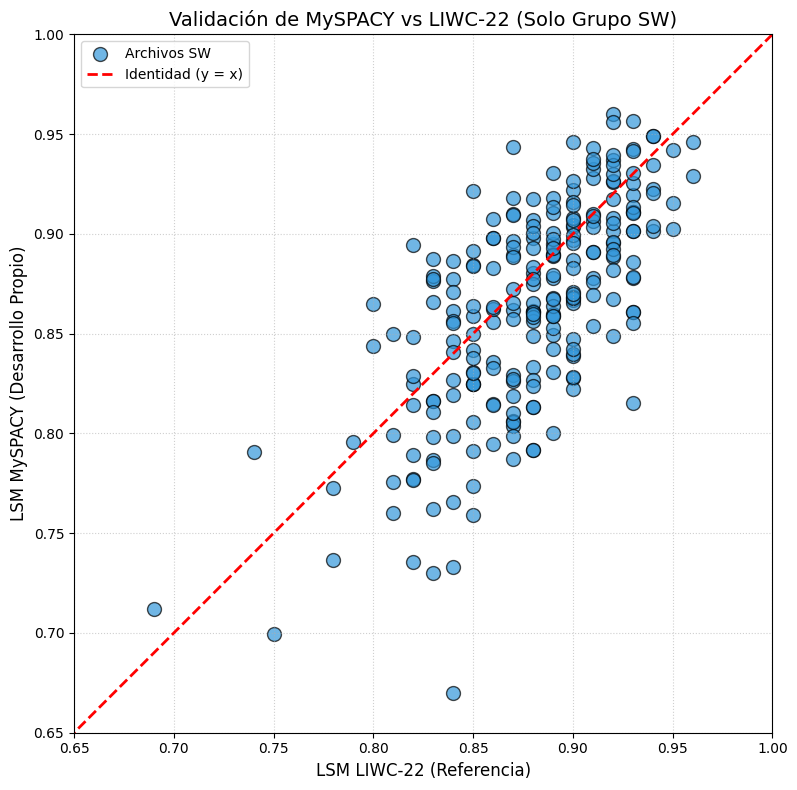

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_identidad_sw(csv_path):
    # 1. Cargar datos
    df = pd.read_csv(csv_path)
    
    # 2. Filtrar solo los archivos de Switchboard (grupo 'output')
    df_sw = df[df['grupo'] == 'SW_PROCESSED'].copy()
    
    if df_sw.empty:
        print("No se encontraron datos para el grupo 'SW_PROCESSED'.")
        return

    # 3. Configuración del gráfico
    plt.figure(figsize=(10, 8))
    
    # 4. Dibujar los puntos (LIWC en X, Spacy en Y)
    plt.scatter(df_sw['lsm_liwc'], df_sw['lsm_spacy'], 
                color='#3498db', s=100, alpha=0.7, edgecolors='black', label='Archivos SW')

    # 5. Dibujar la línea de identidad (y = x)
    # Buscamos el rango min y max para que la línea cubra todo el espectro de los datos
    min_val = min(df_sw['lsm_liwc'].min(), df_sw['lsm_spacy'].min()) - 0.05
    max_val = max(df_sw['lsm_liwc'].max(), df_sw['lsm_spacy'].max()) + 0.05
    identidad = np.linspace(min_val, max_val, 100)
    
    plt.plot(identidad, identidad, color='red', linestyle='--', linewidth=2, label='Identidad (y = x)')

    # 6. Etiquetas de texto para cada punto (opcional, para identificar el archivo)
    #for i, row in df_sw.iterrows():
        #nombre_corto = row['archivo'].replace('.txt', '').replace('.phrases', '')
        #plt.text(row['lsm_liwc'] + 0.002, row['lsm_spacy'] + 0.002, nombre_corto, fontsize=8)


    # 7. --- MODIFICACIÓN DE RANGO ---
    plt.xlim(0.65, 1.0)
    plt.ylim(0.65, 1.0)
    # 7. Personalización
    plt.title('Validación de MySPACY vs LIWC-22 (Solo Grupo SW)', fontsize=14)
    plt.xlabel('LSM LIWC-22 (Referencia)', fontsize=12)
    plt.ylabel('LSM MySPACY (Desarrollo Propio)', fontsize=12)
    
    # Forzamos que el gráfico sea cuadrado para que la línea de 45° se vea bien
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('grafico_identidad_sw.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    # Asegúrate de que esta sea la ruta correcta a tu CSV generado por el pipeline
    ruta_csv_SW = "/home/tgallo/Documents/Proyecto_modular/datos_para_plotear.csv"
    ruta_csv_CGC = "/home/tgallo/Documents/Proyecto_modular/datos_para_plotear_limpios.csv"   
    plot_identidad_sw(ruta_csv_SW)

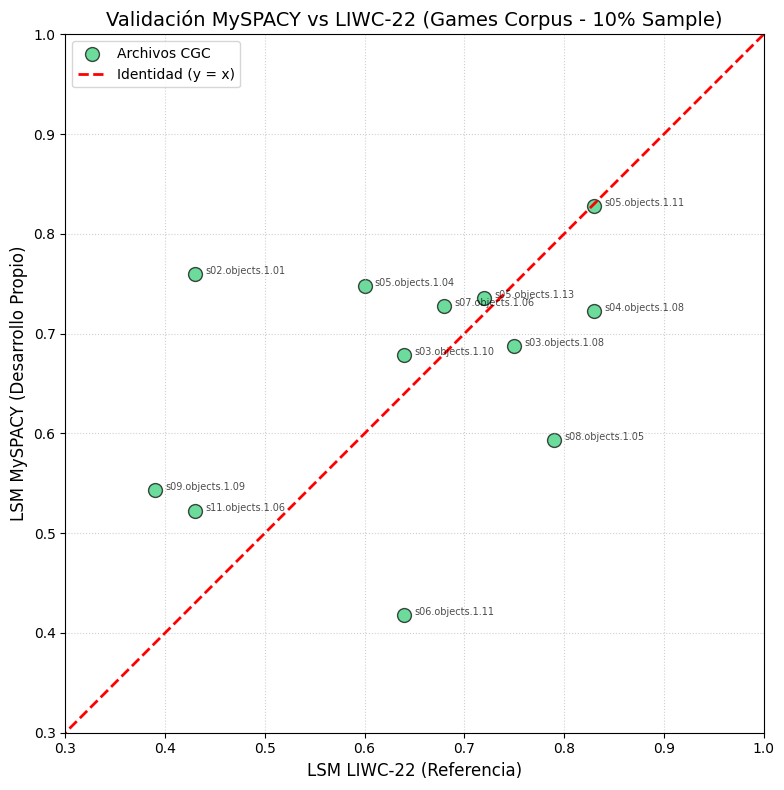

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_identidad_cgc(csv_path):
    # 1. Cargar datos
    df = pd.read_csv(csv_path)
    
    # 2. Filtrar solo los archivos de Games Corpus
    df_cgc = df[df['grupo'] == 'GAMES_CORPUS'].copy()
    
    if df_cgc.empty:
        print("No se encontraron datos para el grupo 'GAMES_CORPUS'.")
        return

    # 3. Configuración del gráfico
    plt.figure(figsize=(10, 8))
    
    # 4. Dibujar los puntos (Color Verde Esmeralda para diferenciar de SW)
    plt.scatter(df_cgc['lsm_liwc'], df_cgc['lsm_spacy'], 
                color='#2ecc71', s=100, alpha=0.7, edgecolors='black', label='Archivos CGC')

    # 5. Línea de identidad (y = x)
    # En CGC el rango es mayor, así que trazamos de 0 a 1 para referencia total
    identidad = np.linspace(0, 1, 100)
    plt.plot(identidad, identidad, color='red', linestyle='--', linewidth=2, label='Identidad (y = x)')

    # 6. Etiquetas de texto (Opcional)
    # Filtramos para no saturar: solo poner nombre si el valor es muy bajo (outliers)
    for i, row in df_cgc.iterrows():
            nombre_corto = row['archivo'].replace('.txt', '').replace('.phrases', '')
            plt.text(row['lsm_liwc'] + 0.01, row['lsm_spacy'], nombre_corto, fontsize=7, alpha=0.7)

    # 7. --- AJUSTE DE RANGO PARA CGC ---
    # Usamos 0.3 como mínimo porque el CGC tiene valores bastante bajos
    plt.xlim(0.3, 1.0)
    plt.ylim(0.3, 1.0)
    
    # 8. Personalización
    plt.title('Validación MySPACY vs LIWC-22 (Games Corpus - 10% Sample)', fontsize=14)
    plt.xlabel('LSM LIWC-22 (Referencia)', fontsize=12)
    plt.ylabel('LSM MySPACY (Desarrollo Propio)', fontsize=12)
    
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.savefig('grafico_identidad_cgc.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    # Ruta al CSV limpio que generamos en el paso anterior
    ruta_csv_CGC = "/home/tgallo/Documents/Proyecto_modular/datos_para_plotear_limpios.csv"   
    plot_identidad_cgc(ruta_csv_CGC)

## CODIGO INTEGRADO QUE ADEMAS CALCULA LA COR PEARSON

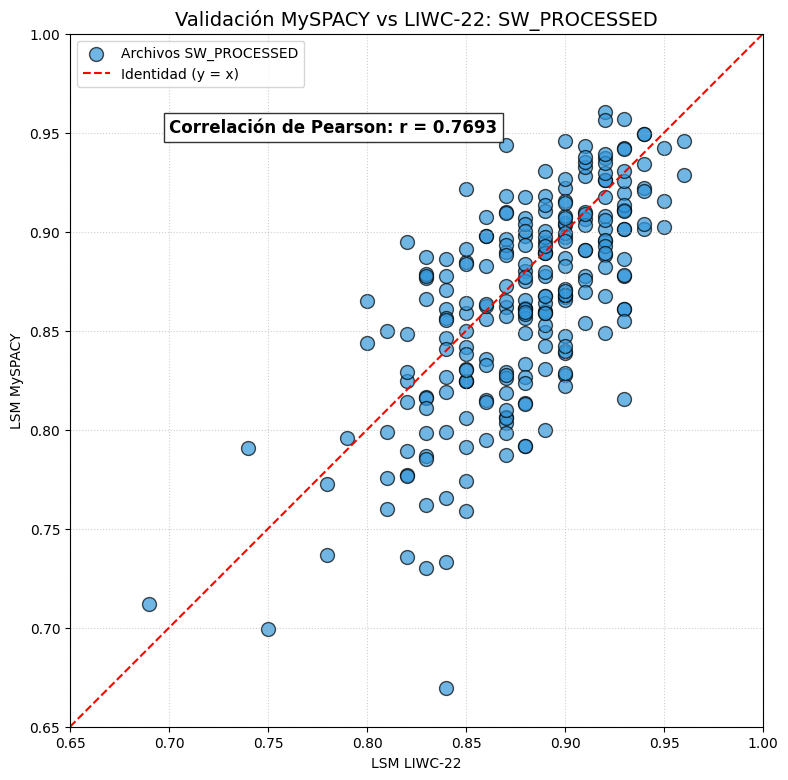

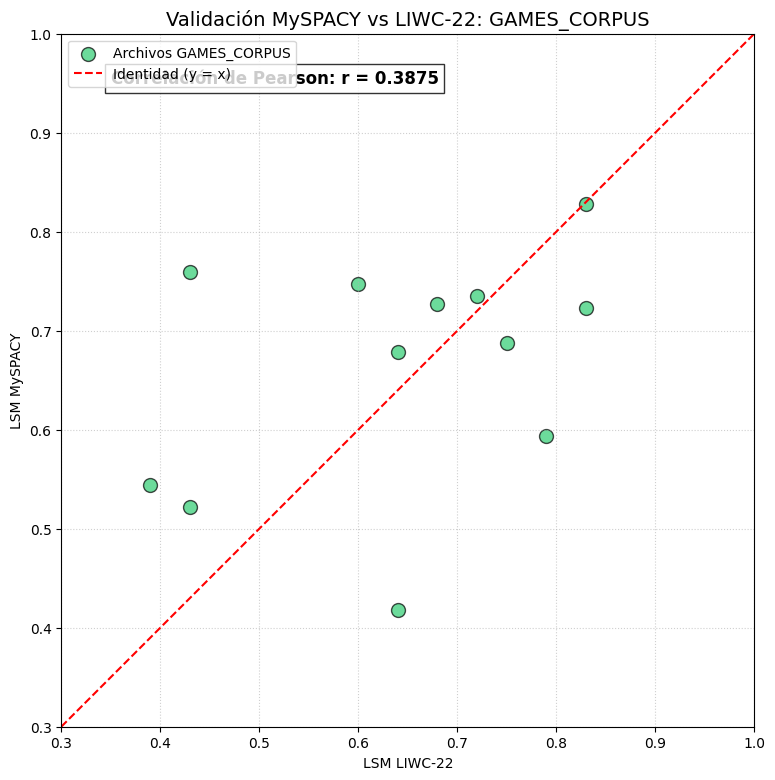

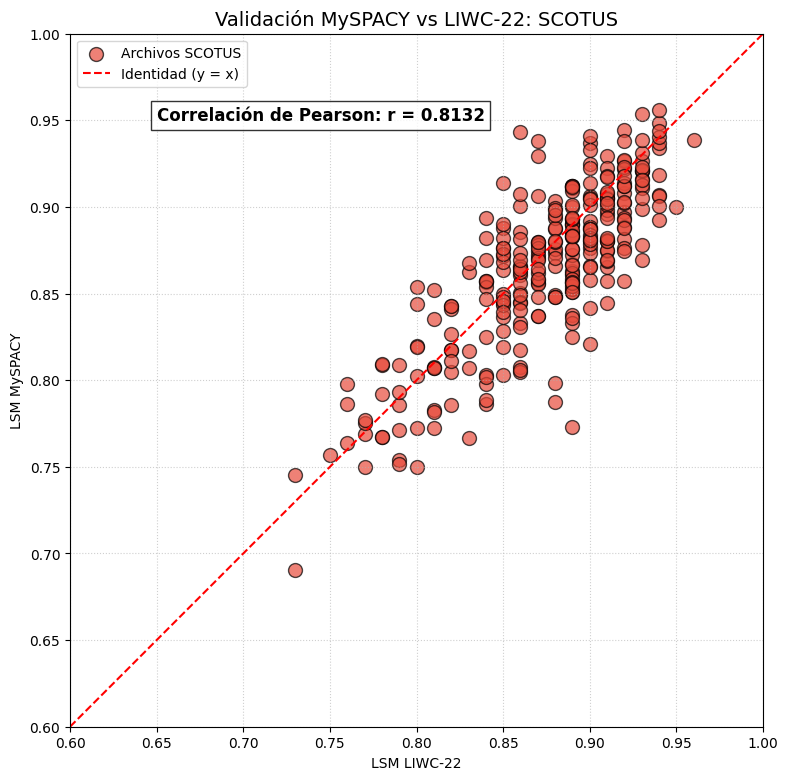

In [15]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr  # <-- Nueva importación

ruta_csv_SW = "/home/tgallo/Documents/Proyecto_modular/datos_para_plotear.csv"
ruta_csv_CGC = "/home/tgallo/Documents/Proyecto_modular/datos_para_plotear_limpios.csv"
ruta_csv_SCOTUS = "/home/tgallo/Documents/Proyecto_modular/datos_para_plotear_SCOTUS.csv"

def plot_identidad_con_correlacion(csv_path, grupo_nombre, color_puntos, rango_min):
    df = pd.read_csv(csv_path)
    df_filtrado = df[df['grupo'] == grupo_nombre].copy()
    
    if df_filtrado.empty:
        return

    # --- CÁLCULO DE PEARSON ---
    # Calculamos la correlación entre las dos columnas
    r_value, p_value = pearsonr(df_filtrado['lsm_liwc'], df_filtrado['lsm_spacy'])
    # --------------------------

    plt.figure(figsize=(9, 9))
    plt.scatter(df_filtrado['lsm_liwc'], df_filtrado['lsm_spacy'], 
                color=color_puntos, s=100, alpha=0.7, edgecolors='black', label=f'Archivos {grupo_nombre}')

    # Línea de identidad
    identidad = np.linspace(rango_min, 1, 100)
    plt.plot(identidad, identidad, color='red', linestyle='--', label='Identidad (y = x)')

    # --- TEXTO DE CORRELACIÓN EN EL GRÁFICO ---
    # Lo ubicamos en la parte inferior derecha
    plt.text(rango_min + 0.05, 0.95, f'Correlación de Pearson: r = {r_value:.4f}', 
             fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))
    # ------------------------------------------

    plt.xlim(rango_min, 1.0)
    plt.ylim(rango_min, 1.0)
    plt.title(f'Validación MySPACY vs LIWC-22: {grupo_nombre}', fontsize=14)
    plt.xlabel('LSM LIWC-22')
    plt.ylabel('LSM MySPACY')
    plt.gca().set_aspect('equal')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    plt.show()

# Ejemplos de uso:
plot_identidad_con_correlacion(ruta_csv_SW, 'SW_PROCESSED', '#3498db', 0.65)
plot_identidad_con_correlacion(ruta_csv_CGC, 'GAMES_CORPUS', '#2ecc71', 0.30)
plot_identidad_con_correlacion(ruta_csv_SCOTUS, 'SCOTUS', '#e74c3c', 0.60)